In [ ]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

In [2]:
(X_train, y_train) , (X_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [3]:
print(f"X_train: shape: {X_train.shape}\n")
print(f"y_train: shape: {y_train.shape}\n")
print(f"X_test: shape: {X_test.shape}\n")
print(f"y_test: shape: {y_test.shape}\n")

X_train: shape: (60000, 28, 28)

y_train: shape: (60000,)

X_test: shape: (10000, 28, 28)

y_test: shape: (10000,)



<class 'numpy.ndarray'>


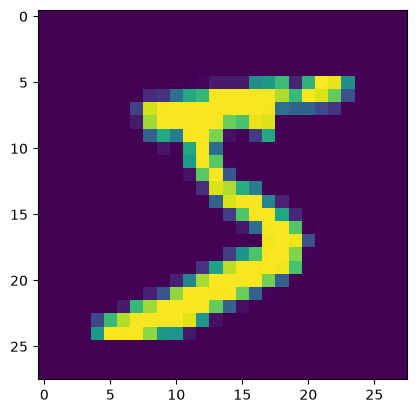

In [5]:
import matplotlib.pyplot as plt
print(type(X_train[0]))
plt.imshow(X_train[0])

In [ ]:
import numpy as np

def preprocess(imgs: np.ndarray, standardize: bool = False) -> np.ndarray:
    """
    Preprocesses a batch of raw MNIST images (pixel range 0–255) for Neural Network training.
    
    Parameters:
        imgs (np.ndarray): Raw batch of images, shape (N, 28, 28) or (N, 784).
        standardize (bool): If True, applies Z-score normalization (mean=0.1307, std=0.3081).
        
    Returns:
        np.ndarray: Preprocessed float32 array ready for PyTorch / TensorFlow.
    """
    # Step 1 & 2: Cast to float32 and rescale pixels from [0, 255] to [0.0, 1.0]
    imgs_float = imgs.astype(np.float32) / 255.0
    
    # Step 3 (Optional): Apply Z-score standardization using global MNIST dataset stats
    if standardize:
        imgs_float = (imgs_float - 0.1307) / 0.3081
        
    return imgs_float


In [13]:
import tensorflow as tf
from tensorflow.keras import layers, models
# One layer perceptron
perceptron = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Flatten(),
    layers.Dense(10, activation='sigmoid')
], name="MNIST_single_perceptron")

In [14]:
perceptron.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
perceptron.fit(X_train, y_train, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.3585 - loss: 9.9221 
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.3616 - loss: 5.9994
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 903us/step - accuracy: 0.3514 - loss: 5.6885
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.3427 - loss: 5.4632
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.3350 - loss: 5.5115


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3427 - loss: 6.6700  
[6.6699748039245605, 0.3427000045776367]
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 706us/step
[2.8268113e-17 0.0000000e+00 1.4381977e-25 1.0000000e+00 1.6011320e-04
 1.0000000e+00 0.0000000e+00 1.0000000e+00 1.0000000e+00 1.0000000e+00]
3


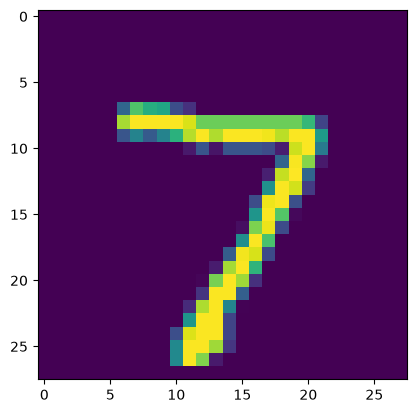

In [15]:
print(perceptron.evaluate(X_test, y_test))
y_pred = perceptron.predict(X_test)
print(y_pred[0])
print(np.argmax(y_pred[0]))
plt.imshow(X_test[0])

In [ ]:
import torch
import torch.nn as nn

def MNIST_MLP(nn.Module):
    def __init__(self):
        super().__init__()
        # Fully connected layers
        self.fc1 = nn.Linear(in_features=28*28, out_features=128)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(in_features=128, out_features=64)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(in_features=64, out_features=10)
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # [B, 1, 28, 28] -> [B, 784]
        x = x.view(x.size(0), -1)
        # [B, 784] -> [B, 128]
        x = self.fc1(x)
        # [B, 128] -> [B, 64]
        x = self.relu1(x)
        x = self.fc2(x)
        # [B, 64] -> [B, 10]
        x = self.relu2(x)
        logits = self.fc3(x)
        return logits

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
class Trainer:
    def __init__(self, model, optimizer, criterion, metrics, epochs=100, batch_size=64):
        self.model = model
        self.optimizer = optimizer
        self.criterion = criterion
        self.metrics = metrics
        self.epochs = epochs
        self.batch_size = batch_size
    
    def fit(self, X, y):
        X_train, X_test, y_train, y_test = train_test_split(X.numpy(), y.numpy(), test_size=0.2, random_state=42)
        train_ds = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32))
        test_ds = TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.float32))
        train_loader = DataLoader(train_ds, batch_size=self.batch_size)
        test_loader = DataLoader(test_ds, batch_size=self.batch_size)
        losses_train, losses_test = [], []
        accuracies_train, accuracies_test = [], []
    
        for epoch in range(1, self.epochs + 1):
            train_loss, train_acc = self.run_epoch(train_loader, mode="train")
            test_loss, test_acc = self.run_epoch(test_loader, mode="test")
    
            losses_train.append(train_loss)
            losses_test.append(test_loss)
            accuracies_train.append(train_acc)
            accuracies_test.append(test_acc)
    
            print(f"Epoch [{epoch}/{self.epochs}] | "
                f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% |"f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%")
    
        # Visualization
        self.plot_metrics(losses_train, losses_test, "Loss Curves", "Loss")
        self.plot_metrics(accuracies_train, accuracies_test, "AccuracyCurves", "Accuracy (%)")
    
    def run_epoch(self, dataloader: DataLoader, mode: str):
        is_train = (mode == "train")
        if is_train:
            self.model.train()
        else:
            self.model.test()
        total_loss = 0.0
        correct = 0
        total_samples = 0

        with torch.set_grad_enabled(is_train):
            for batch_X, batch_y in dataloader:
                # batch_x: [Batch, 784], batch_y: [Batch, 1]
                logits = self.model(batch_X)
                loss = self.criterion(logits, batch_y)

                if is_train:
                    self.optimizer.zero_grad()
                    loss.backward()
                    self.optimizer.step()
                total_loss += loss.item() * batch_X.size(0)
                preds = torch.argmax(logits, dim=1)
                correct += (preds == batch_y).sum().item()
                total_samples += batch_y.size(0)
        epoch_loss = total_loss / total_samples
        epoch_acc = correct / total_samples

        return epoch_loss, epoch_acc

    def plot_metrics(self, train_vals, test_vals, title: str, ylabel: str):
        plt.figure(figsize=(8, 5))
        epochs_range = np.arange(1, self.epochs + 1)
        plt.plot(epochs_range, train_vals, label="Train", marker='o')
        plt.plot(epochs_range, test_vals, label="Test", marker='s')
        plt.title(title)
        plt.xlabel("Epochs")
        plt.ylabel(ylabel)
        plt.legend()
        plt.grid(True)
        plt.show()